In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows의 경우
plt.rcParams['axes.unicode_minus'] = False  # 음수 기호 깨짐 방지

In [ ]:
# 작물 교체
crop = "사과"
df = pd.read_csv(f"data/{crop}_lag처리.csv", encoding="cp949")


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116453 entries, 0 to 116452
Data columns (total 41 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              116453 non-null  int64  
 1   week              116453 non-null  int64  
 2   week_start        116453 non-null  object 
 3   품종코드              116453 non-null  int64  
 4   등급코드              116453 non-null  int64  
 5   직팜산지코드            116453 non-null  int64  
 6   총거래량(kg)          116453 non-null  float64
 7   일평균기온             116453 non-null  float64
 8   최고기온              116453 non-null  float64
 9   최저기온              116453 non-null  float64
 10  평균상대습도            116453 non-null  float64
 11  강수량(mm)           116453 non-null  float64
 12  1시간최고강수량(mm)      116453 non-null  float64
 13  holiday_flag      116453 non-null  int64  
 14  holiday_score     116453 non-null  float64
 15  grow_score        116453 non-null  float64
 16  평균단가(원)           11

In [4]:
print("✅ 결측치 개수:\n", df.isna().sum())
print("✅ 전체 결측치 합:", df.isna().sum().sum())
print("✅ 중복 행 수:", df.duplicated().sum())


✅ 결측치 개수:
 year                0
week                0
week_start          0
품종코드                0
등급코드                0
직팜산지코드              0
총거래량(kg)            0
일평균기온               0
최고기온                0
최저기온                0
평균상대습도              0
강수량(mm)             0
1시간최고강수량(mm)        0
holiday_flag        0
holiday_score       0
grow_score          0
평균단가(원)             0
일평균기온_t-1           0
최고기온_t-1            0
최저기온_t-1            0
평균상대습도_t-1          0
강수량(mm)_t-1         0
1시간최고강수량(mm)_t-1    0
일평균기온_t-2           0
최고기온_t-2            0
최저기온_t-2            0
평균상대습도_t-2          0
강수량(mm)_t-2         0
1시간최고강수량(mm)_t-2    0
일평균기온_t-3           0
최고기온_t-3            0
최저기온_t-3            0
평균상대습도_t-3          0
강수량(mm)_t-3         0
1시간최고강수량(mm)_t-3    0
일평균기온_t-4           0
최고기온_t-4            0
최저기온_t-4            0
평균상대습도_t-4          0
강수량(mm)_t-4         0
1시간최고강수량(mm)_t-4    0
dtype: int64
✅ 전체 결측치 합: 0
✅ 중복 행 수: 0


In [5]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("🔢 수치형 컬럼:", numerical_cols)
print("🔤 범주형 컬럼:", categorical_cols)


🔢 수치형 컬럼: ['year', 'week', '품종코드', '등급코드', '직팜산지코드', '총거래량(kg)', '일평균기온', '최고기온', '최저기온', '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)', 'holiday_flag', 'holiday_score', 'grow_score', '평균단가(원)', '일평균기온_t-1', '최고기온_t-1', '최저기온_t-1', '평균상대습도_t-1', '강수량(mm)_t-1', '1시간최고강수량(mm)_t-1', '일평균기온_t-2', '최고기온_t-2', '최저기온_t-2', '평균상대습도_t-2', '강수량(mm)_t-2', '1시간최고강수량(mm)_t-2', '일평균기온_t-3', '최고기온_t-3', '최저기온_t-3', '평균상대습도_t-3', '강수량(mm)_t-3', '1시간최고강수량(mm)_t-3', '일평균기온_t-4', '최고기온_t-4', '최저기온_t-4', '평균상대습도_t-4', '강수량(mm)_t-4', '1시간최고강수량(mm)_t-4']
🔤 범주형 컬럼: ['week_start']


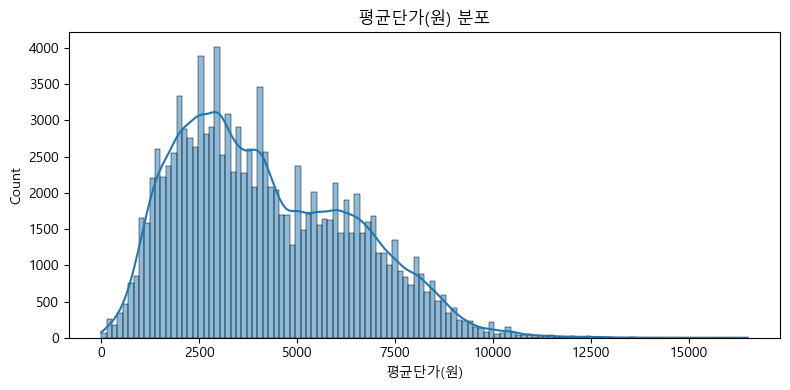

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df['평균단가(원)'], kde=True)
plt.title("평균단가(원) 분포")
plt.tight_layout()
plt.show()


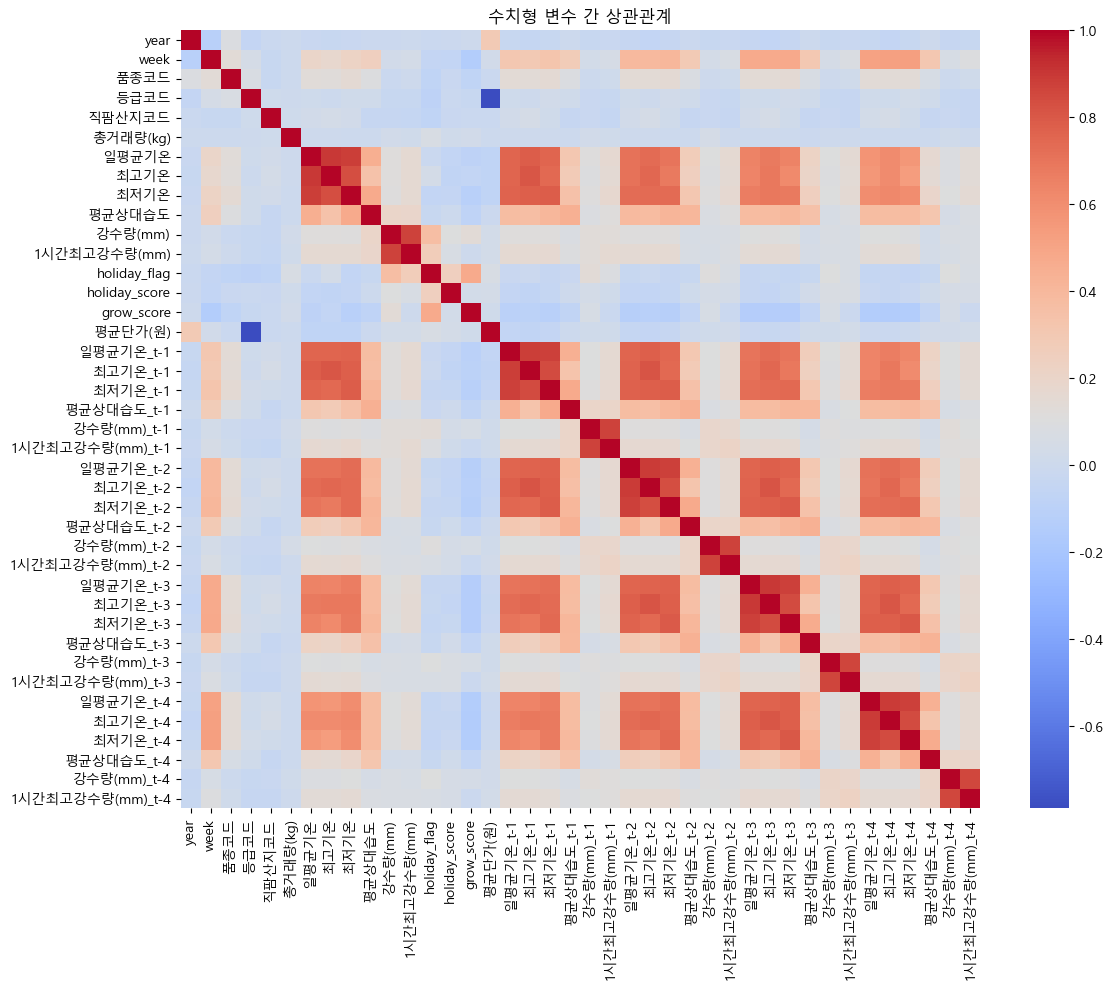

In [9]:
plt.figure(figsize=(12, 10))
corr = df[numerical_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("수치형 변수 간 상관관계")
plt.tight_layout()
plt.show()


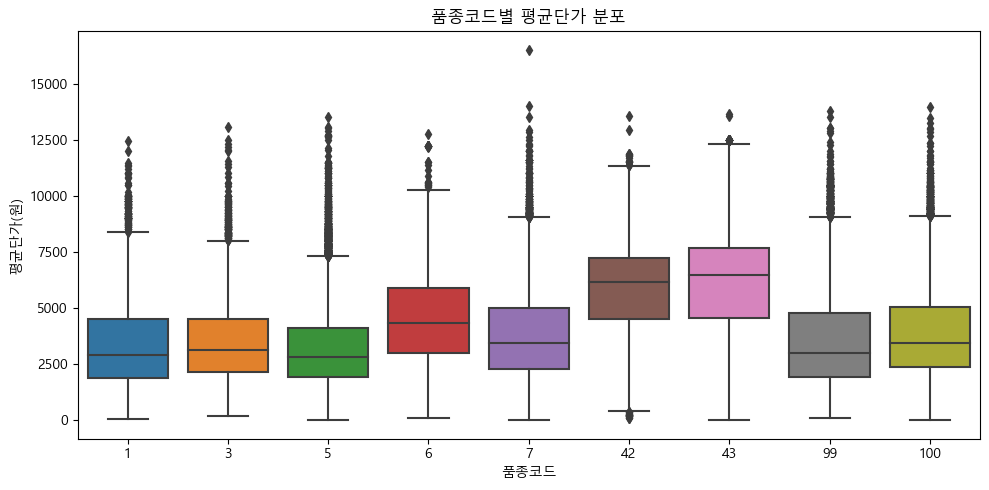

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='품종코드', y='평균단가(원)')
plt.title("품종코드별 평균단가 분포")
plt.tight_layout()
plt.show()


In [14]:
corr_target = corr['평균단가(원)'].sort_values(ascending=False)
print(corr_target)


평균단가(원)             1.000000
year                0.293446
holiday_flag        0.067804
holiday_score       0.040968
1시간최고강수량(mm)_t-4    0.033378
1시간최고강수량(mm)        0.030382
강수량(mm)             0.030188
1시간최고강수량(mm)_t-3    0.030101
week                0.025994
1시간최고강수량(mm)_t-2    0.024114
강수량(mm)_t-4         0.023676
평균상대습도_t-4          0.023435
강수량(mm)_t-3         0.020789
1시간최고강수량(mm)_t-1    0.020184
grow_score          0.019824
평균상대습도_t-3          0.017861
강수량(mm)_t-2         0.015969
강수량(mm)_t-1         0.014763
평균상대습도_t-2          0.006726
최저기온_t-4           -0.005353
총거래량(kg)           -0.006002
평균상대습도_t-1         -0.006244
일평균기온_t-4          -0.009454
평균상대습도             -0.009915
직팜산지코드             -0.016148
품종코드               -0.016897
최고기온_t-4           -0.018483
최저기온_t-3           -0.021858
일평균기온_t-3          -0.025797
최고기온_t-3           -0.034914
최저기온_t-2           -0.039205
일평균기온_t-2          -0.042701
최고기온_t-2           -0.050168
최저기온_t-1           -0.055997
일평균기온_t-1     

<Axes: xlabel='등급코드', ylabel='평균단가(원)'>

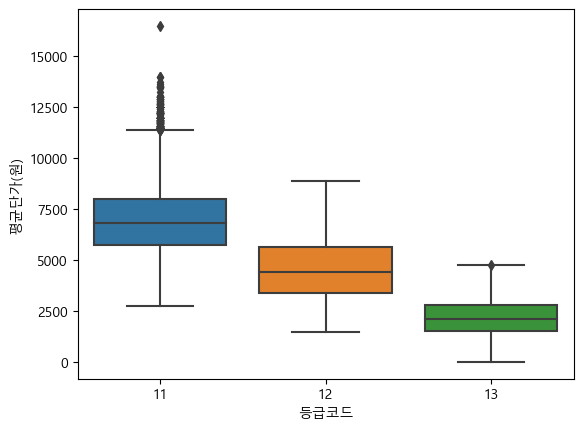

In [15]:
sns.boxplot(x='등급코드', y='평균단가(원)', data=df)


<Axes: xlabel='총거래량(kg)'>

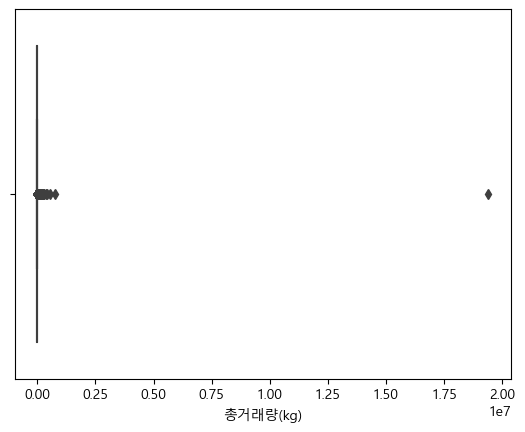

In [17]:
sns.boxplot(x=df['총거래량(kg)'])

In [19]:
from scipy.stats import zscore
df['zscore'] = zscore(df['총거래량(kg)'])
df[df['zscore'].abs() > 3]



,year,week,week_start,품종코드,등급코드,직팜산지코드,총거래량(kg),일평균기온,최고기온,최저기온,...,평균상대습도_t-3,강수량(mm)_t-3,1시간최고강수량(mm)_t-3,일평균기온_t-4,최고기온_t-4,최저기온_t-4,평균상대습도_t-4,강수량(mm)_t-4,1시간최고강수량(mm)_t-4,zscore
4426,2018,22,2018-05-28,99,13,1089,202272.0,20.127778,30.5,14.7,...,84.280000,0.0,0.0,16.383333,22.4,10.9,77.466667,9.4,4.2,3.477859
18903,2019,21,2019-05-20,99,13,1121,181440.0,20.423077,33.5,6.7,...,78.500000,0.0,0.0,15.720000,27.5,8.9,81.320000,16.4,5.2,3.115447
19484,2019,22,2019-05-27,99,13,1089,285637.0,19.868085,28.6,14.2,...,30.800000,0.0,0.0,15.500000,19.2,12.8,88.400000,0.4,0.2,4.928151
20525,2019,24,2019-06-10,99,13,1035,192638.0,19.536585,28.0,12.8,...,68.100000,6.3,5.4,19.650000,29.2,10.6,63.987500,0.8,0.8,3.310258
54521,2021,32,2021-08-09,100,13,1094,238360.0,26.100000,31.0,21.4,...,83.050000,0.0,0.0,24.333333,29.0,18.9,92.200000,147.6,37.4,4.105678
54522,2021,32,2021-08-09,100,13,1109,217000.0,27.000000,32.9,21.9,...,64.600000,0.0,0.0,10.800000,17.6,3.5,65.300000,0.0,0.0,3.734081
54523,2021,32,2021-08-09,100,13,1121,400000.0,27.800000,33.1,23.4,...,70.300000,0.0,0.0,26.900000,34.0,24.2,78.400000,5.8,5.8,6.917711
54664,2021,32,2021-08-09,99,13,1159,220000.0,25.300000,28.1,22.7,...,82.400000,0.3,0.3,22.700000,27.0,18.8,74.200000,0.0,0.0,3.786271
54977,2021,34,2021-08-23,100,13,1093,387360.0,26.200000,30.2,23.7,...,75.900000,0.0,0.0,28.300000,32.4,24.9,74.100000,0.0,0.0,6.697815
55120,2021,34,2021-08-23,99,13,1138,560200.0,25.575000,34.4,21.2,...,65.550000,0.0,0.0,28.350000,34.2,23.1,60.850000,0.0,0.0,9.704693


In [ ]:
for col in ['총거래량(kg)', '일평균기온']:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


KeyboardInterrupt: 